# Experimentation and Implementation

I plan on using this python notebook as a way to formulate how my neural networks should work. If you are reading this without having read the README.md I will quickly explain the goals of this project:

This project is meant to serve both as an introduction to protein folding via machine learning, and to test the potential strength of a relatively new algorithm named 'ProtTrans' which can take a string of protein residues and transform the input into a string that would be easier to read and train a neural network on for feasable proteins.

As a quick mark, here are the things I need to do in this file:
1) Import protein residue data
2) Processes, refine, and reduce data so that the nn can be trained quickly to experiment and adapt
3) build and train neural network that takes in residues straight.
4) incorporate ProtTrans, feed data in, and store output
5) build and train another neural network on ProtTrans output data
6) Optimize hyperparameters for both neural networks and experiment with various values like depth and # of hidden nodes.
7) print graphs and data to compare and analyize

I am not entirely sure what type of output the cnn should provide, it can either provide a 0-1 value of certainty of contact, then we use a cutoff to decide what is a contact or not, or it can provide a distance metric that we then filter to however many A we want to use to denote a "contact"


# Imports and dependencies

In [1]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import islice
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device}")


Using cpu


# Importing Protein Data

I will use the following code box to try and visualize the data given in the 'adataset' pdb file. 

The key features I need to be able to extract are name, length, amino acid residues, and the contact map.

A lot of this is written in a way that should make it easy to apply this to the whole database.

4LGTD
247
['M', 'S', 'E', 'K', 'L', 'Q', 'K', 'V', 'L', 'A', 'R', 'A', 'G', 'H', 'G', 'S', 'R', 'R', 'E', 'I', 'E', 'S', 'I', 'I', 'E', 'A', 'G', 'R', 'V', 'S', 'V', 'D', 'G', 'K', 'I', 'A', 'K', 'L', 'G', 'D', 'R', 'V', 'E', 'V', 'T', 'P', 'G', 'L', 'K', 'I', 'R', 'I', 'D', 'G', 'H', 'L', 'I', 'S', 'V', 'R', 'E', 'S', 'I', 'C', 'R', 'V', 'L', 'A', 'Y', 'Y', 'K', 'P', 'E', 'G', 'E', 'L', 'C', 'T', 'R', 'N', 'D', 'P', 'E', 'G', 'R', 'P', 'T', 'V', 'F', 'D', 'R', 'L', 'P', 'K', 'L', 'R', 'G', 'A', 'R', 'W', 'I', 'A', 'V', 'G', 'R', 'L', 'D', 'V', 'N', 'T', 'X', 'G', 'L', 'L', 'L', 'F', 'T', 'T', 'D', 'G', 'E', 'L', 'A', 'N', 'R', 'L', 'M', 'H', 'P', 'S', 'R', 'E', 'V', 'E', 'R', 'E', 'Y', 'A', 'V', 'R', 'V', 'F', 'G', 'Q', 'V', 'D', 'D', 'A', 'K', 'L', 'R', 'D', 'L', 'S', 'R', 'G', 'V', 'Q', 'L', 'E', 'D', 'G', 'P', 'A', 'A', 'F', 'K', 'T', 'I', 'K', 'F', 'S', 'G', 'G', 'E', 'G', 'I', 'N', 'Q', 'W', 'Y', 'N', 'V', 'T', 'L', 'T', 'E', 'G', 'R', 'N', 'R', 'E', 'V', 'R', 'R', 'L', 'W', 'E',

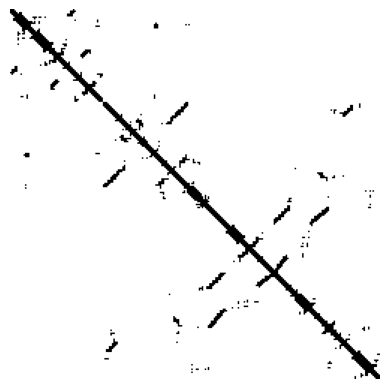

In [2]:
with open("pdb.fasta_qual.16Nov2022.adataset") as pdb_adataset:
    # Extract the data we need from the slice of the dataset
    segment = list(islice(pdb_adataset, 16))
    data = {"name": [], "length": [], "proteins": [], "xyz": []}
    data["name"].append(segment[0].replace("\n", ""))
    data["length"].append(int(segment[1]))

    # protein and coords need extra care, as they are lists in the dict list
    data["proteins"].append(
        segment[2].replace("\n", "")
            .split("\t")
    )
    del data["proteins"][0][-1]

    data["xyz"].append(
        segment[13].replace("\n", "")
            .split("\t")
        )
    del data["xyz"][0][-1]

    # We are going to use a for loop to turn the xyz coordinates into floats and make the triplet lists
    i = 0
    for string in data["xyz"][0]:
        data["xyz"][0][i] = list(map(float, string.split(" ")))
        i += 1

print(data["name"][0])
print(data["length"][0])
print(data["proteins"][0])
print(len(data["proteins"][0]))
print(data["xyz"][0])
print(len(data["xyz"][0]))

# Calculating and printing the contact map
contact = []
for coord1 in data["xyz"][0]:
    temp = []
    for coord2 in data["xyz"][0]:
        distance = np.linalg.norm(np.array(coord1) - np.array(coord2))
        if (distance <= 8): val = 0
        else: val = 1
        temp.append(val)
    contact.append(temp)

def applyThreshold(tensor, threshold, length):  
    map = []
    for i, line in enumerate(tensor, 0):
        if i == length: break
        temp_line = []
        for element in line[:length]:
            if (element < threshold):
                temp_line.append(0.)
            else:
                temp_line.append(1.)
        map.append(temp_line)
    return map

def printMap(map, size = -1):
    if size > 0:
        newMap = map[:size, :size]
    else:
        newMap = map
    fig, ax = plt.subplots()
    ax.imshow(np.matrix(newMap), cmap='gray')
    ax.axis('off')
    plt.show()

printMap(contact)

## Loading in data from dataset

This is a large text box, though its functionality is not complicated. The class loads in the data from the file, then encodes the protein resiude list using VHSE encodings, which are then concatenated into pairs to represent the tensors, the train tensors are a Length x Length grid of vectors of length 16 (8 per residue in each pair). The test data takes the coordinates given by the database to make a tensor of L x L with each value being the distance between each protein (as seen above)

Previously calculated statistics:

Max length:  1195 	Min length:  30 	Mean length:  219.79 	Mode length:  233

Chars used in proteins:  {'N', 'F', 'P', 'A', 'D', 'M', 'T', 'G', 'Q', 'H', 'I', 'K', 'W', 'Y', 'X', 'V', 'S', 'E', 'C', 'R', 'L'} 	Count:  21

In [3]:
from tqdm import tqdm

MAXLENGTH = 300

vhse_map = {
    'A': [0.15, -1.11, -1.35, -0.92, 0.02, -0.91, 0.36, -0.48],
    'R': [-1.47, 1.45, 1.24, 1.27, 1.55, 1.47, 1.3, 0.83],
    'N': [-0.99, 0, -0.37, 0.69, -0.55, 0.85, 0.74, -0.8],
    'D': [-1.15, 0.67, -0.41, -0.01, -2.68, 1.31, 0.03, 0.56],
    'C': [0.18, -1.67, -0.46, -0.21, 0, 1.2, -1.61, -0.19],
    'Q': [-0.96, 0.12, 0.18, 0.16, 0.09, 0.42, -0.2, -0.41],
    'E': [-1.18, 0.4, 0.1, 0.36, -21.6, -0.17, 0.91, 0.02],
    'G': [-0.2, -1.53, -2.63, 2.28, -0.53, -1.18, 2.01, -1.34],
    'H': [-0.43, -0.25, 0.37, 0.19, 0.51, 1.28, 0.93, 0.65],
    'I': [1.27, -0.14, 0.3, -1.8, 0.3, -1.61, -0.16, -0.13],
    'L': [1.36, 0.07, 0.26, -0.8, 0.22, -1.37, 0.08, -0.62],
    'K': [-1.17, 0.7, 0.7, 0.8, 1.64, 0.67, 1.63, 0.13],
    'M': [1.01, -0.53, 0.43, 0, 0.23, 0.1, -0.86, -0.68],
    'F': [1.52, 0.61, 0.96, -0.16, 0.25, 0.28, -1.33, -.02],
    'P': [0.22, -0.17, -0.5, 0.05, -0.01, -1.34, -0.19, 3.56],
    'S': [-0.67, -0.88, -1.07, -0.41, -0.32, 0.27, -0.64, 0.11],
    'T': [-0.34, -0.51, -0.55, -1.06, 0.01, -0.01, -0.79, 0.39],
    'W': [1.5, 2.06, 1.79, 0.75, 0.75, -0.13, -1.06, -0.85],
    'Y': [0.61, 1.6, 1.17, 0.73, 0.53, 0.25, -0.96, -0.52],
    'V': [0.76, -0.92, 0.17, -1.91, 0.22, -1.4, -0.24, -0.03],
    'X': [0, 0, 0, 0, 0, 0, 0, 0],
}

# Read in data from the two files
print("Reading in from dataset files")

with open("pdb.fasta_qual.16Nov2022_30.fasta") as pdb_fasta:
    fasta_lines = pdb_fasta.readlines()[0::2]
fasta_lines = [s.replace('>', '') for s in fasta_lines]
fasta_lines = [s.replace('\n', '') for s in fasta_lines]

data = {"name": [], "length": [], "proteins": [], "coord": []}
i = 0

with open("pdb.fasta_qual.16Nov2022.adataset") as pdb_adataset:
    while True:
        segment = list(islice(pdb_adataset, 16))
        if not segment: # If there are no more lines we break the loop.
            break

        name = segment[0].replace("\n", "")
        if name in fasta_lines:
            length = int(segment[1])
            if (length <= MAXLENGTH):
                data["name"].append(name)
                data["length"].append(length)

                # Residue data
                proteins = segment[2].replace("\n", "").split("\t")
                del proteins[-1]
                data["proteins"].append(proteins)

                # Coordinate data
                coords = segment[13].replace("\n", "").split("\t")
                del coords[-1]

                i = 0
                for string in coords:
                    coords[i] = list(map(float, string.split(" ")))
                    i += 1
                data["coord"].append(coords) 
print("Finished reading from files.")   

# Pad coordinates to MAXLENGTH
print("Extending coordinates to MAXLENGTH")
for protein in tqdm(data['coord']):
    while len(protein) < MAXLENGTH:
        protein.append([0.0, 0.0, 0.0])

# Convert proteins to encodings
print("Encoding protein residues")
encoded_prots = []
for protein in tqdm(data['proteins']):
    temp_encoding = []
    for residue in protein:
        temp_encoding.append(vhse_map[residue])
    while len(temp_encoding) < MAXLENGTH:
        # Normalize the encoded lengths to MAXLENGTH
        temp_encoding.append([0, 0, 0, 0, 0, 0, 0, 0])

    encoded_prots.append(temp_encoding)
        
data['encoded'] = encoded_prots
print("Finished encoding protein residues")

print(f"Name: {data['name'][0]} \tLength: {data['length'][0]} \nResidue Chain: {data['proteins'][0]} \nEncodings: {data['encoded'][0]} \nCoordinates: {data['coord'][0]}")

Reading in from dataset files
Finished reading from files.
Extending coordinates to MAXLENGTH


100%|██████████| 19152/19152 [00:03<00:00, 5218.57it/s]


Encoding protein residues


100%|██████████| 19152/19152 [00:05<00:00, 3655.68it/s]

Finished encoding protein residues
Name: 2KL1A 	Length: 87 
Residue Chain: ['M', 'N', 'E', 'A', 'K', 'G', 'V', 'Y', 'V', 'M', 'S', 'V', 'L', 'P', 'N', 'M', 'P', 'A', 'A', 'G', 'R', 'L', 'E', 'A', 'G', 'D', 'R', 'I', 'A', 'A', 'I', 'D', 'G', 'Q', 'P', 'I', 'N', 'T', 'S', 'E', 'Q', 'I', 'V', 'S', 'Y', 'V', 'R', 'E', 'K', 'Q', 'A', 'G', 'D', 'R', 'V', 'R', 'V', 'T', 'F', 'I', 'R', 'D', 'R', 'K', 'Q', 'H', 'E', 'A', 'E', 'L', 'V', 'L', 'K', 'P', 'F', 'P', 'H', 'H', 'P', 'N', 'Q', 'I', 'G', 'L', 'G', 'V', 'T'] 
Encodings: [[1.01, -0.53, 0.43, 0, 0.23, 0.1, -0.86, -0.68], [-0.99, 0, -0.37, 0.69, -0.55, 0.85, 0.74, -0.8], [-1.18, 0.4, 0.1, 0.36, -21.6, -0.17, 0.91, 0.02], [0.15, -1.11, -1.35, -0.92, 0.02, -0.91, 0.36, -0.48], [-1.17, 0.7, 0.7, 0.8, 1.64, 0.67, 1.63, 0.13], [-0.2, -1.53, -2.63, 2.28, -0.53, -1.18, 2.01, -1.34], [0.76, -0.92, 0.17, -1.91, 0.22, -1.4, -0.24, -0.03], [0.61, 1.6, 1.17, 0.73, 0.53, 0.25, -0.96, -0.52], [0.76, -0.92, 0.17, -1.91, 0.22, -1.4, -0.24, -0.03], [1.01, -0

In [18]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class vhseDataset(Dataset):
    # This does hold it in memory instead of disk,
    # Which could be a problem in the actual script later

    def __init__(self, num_data = -1, test = False):
        self.vhseData = []
        self.target = []
        self.lengths = []

        # Here is where we load the actual data, based on whether its a test set or not
        if num_data >= 1:
            if test:
                dataset = {key: value[-num_data:] for key, value in data.items()}
            else:
                dataset = {key: value[:num_data] for key, value in data.items()}
        else:
            dataset = data
            
        print("Calculating training data")
        # Convert encoded proteins into tensors - we are going to try and use (protein1, protein2, protein1-protein2, protein1+protein2)
        for protein in tqdm(dataset['encoded']):
            protein = np.array(protein)
            tensor = np.concatenate([
                protein[:, None, :].repeat(MAXLENGTH, axis=1), 
                protein[None, :, :].repeat(MAXLENGTH, axis=0),
                protein[:, None, :] - protein[None, :, :],
                protein[:, None, :] + protein[None, :, :]
                ])
            tensor = np.float32(tensor)
            tensor = torch.tensor(tensor)
            tensor = tensor.permute(2, 0, 1)
            tensor = torch.nn.functional.normalize(tensor)
            self.vhseData.append(tensor) 

        print("Calculating target data")
        # Convert residue coords to distances
        for protein in tqdm(dataset['coord']):
            protein = np.array(protein)
            tensor = protein[:, None, :] - protein[None, :, :]
            tensor = np.linalg.norm(tensor, axis=2)
            tensor = applyThreshold(tensor, 8, MAXLENGTH)
            tensor = np.float32(tensor)
            tensor = torch.tensor(tensor).unsqueeze(0)
            self.target.append(tensor)

        print("Store protein lengths")
        for protein in tqdm(dataset['length']):
            self.lengths.append(protein)
    
    def __len__(self):
        return len(self.vhseData)
    
    # If we convert to an hdd read this would be far more complicated.
    # returns the tensor (train or test) and its name as a label
    def __getitem__(self, index):
        return self.vhseData[index], self.target[index], self.lengths[index]

## Creating Train & Test datasets

In [19]:
batch = 10
count = 1000  # -1 Does all data
train_data = vhseDataset(num_data = count)
train_loader = DataLoader(dataset = train_data, batch_size = batch, shuffle = True)
test_data = vhseDataset(num_data = count, test = True)
test_loader = DataLoader(dataset = test_data, batch_size = batch, shuffle=True)

Calculating training data


 89%|████████▉ | 890/1000 [01:01<00:07, 14.46it/s]


MemoryError: Unable to allocate 11.0 MiB for an array with shape (1200, 300, 8) and data type float32

## Visualize data to ensure class functionalitiy

torch.Size([10, 8, 1200, 300])
tensor([[[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [-0.0411, -0.0259, -0.0290,  ..., -0.0411, -0.0411, -0.0411],
          [-0.0334, -0.0211, -0.0236,  ..., -0.0334, -0.0334, -0.0334],
          ...,
          [ 0.0000, -0.0259, -0.0236,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000, -0.0259, -0.0236,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000, -0.0259, -0.0236,  ...,  0.0000,  0.0000,  0.0000]],

         [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0161,  0.0145,  0.0159,  ...,  0.0161,  0.0161,  0.0161],
          [ 0.0048,  0.0043,  0.0048,  ...,  0.0048,  0.0048,  0.0048],
          ...,
          [ 0.0000,  0.0145,  0.0048,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0145,  0.0048,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0145,  0.0048,  ...,  0.0000,  0.0000,  0.0000]],

         [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],

C:\Users\Ryan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchshow\visualization.py:385: UserWarning: Original input range is not 0-1 when using grayscale mode. Auto-rescaling it to 0-1 by default.
  warnings.warn('Original input range is not 0-1 when using grayscale mode. Auto-rescaling it to 0-1 by default.')


tensor([[[0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.]]])


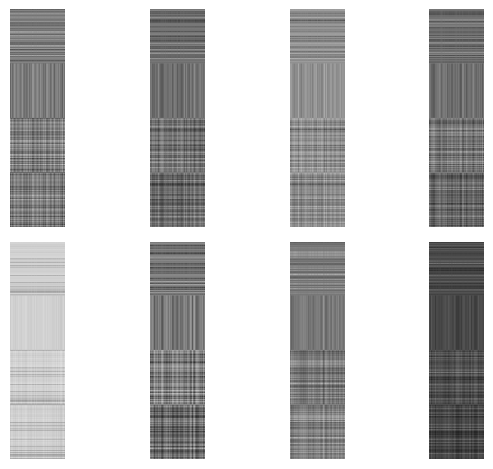

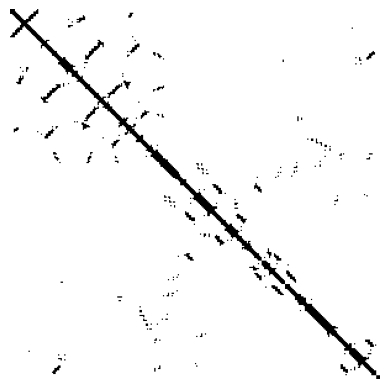

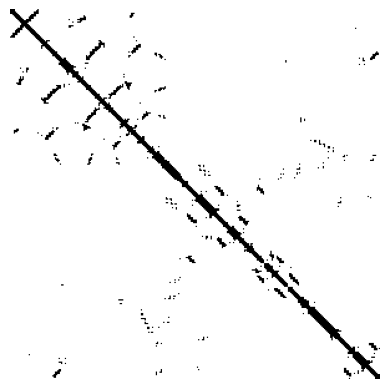

In [9]:
import torchshow
trainiter = iter(train_loader)

# Train data
train, target, length = next(trainiter)
print(train.shape)
train = train.squeeze(0)
print(train)
# This doesn't look how I expected it to, but the printed tensor does
torchshow.show(train[0])

# Target data
target = target[0]
print(target)
printMap(target.squeeze(0))

printMap(target.squeeze(0), length[0])

# Creating a Convolutional Neural Network

In [10]:
class CNN(nn.Module):
    def __init__(self, feat, channels):
        super(CNN, self).__init__()

        self.relu = nn.ReLU(inplace=True)
        self.batch = nn.BatchNorm2d(channels)
        self.conv = nn.Conv2d(feat, channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.final = nn.Conv2d(channels, 1, kernel_size=1)
        
    def forward(self, x):
        
        x = self.batch(self.conv(x))
        x = self.relu(x)
        x = self.batch(self.conv2(x))
        x = self.relu(x)
        x = self.batch(self.conv2(x))
        x = self.relu(x)
        x = self.final(x)
        
        return x

## Testing CNN forward to confirm data works

In [ ]:
import torch.optim as optim

vhse_cnn = CNN(32, 32)
train_loader = DataLoader(dataset = train_data, batch_size = batch, shuffle = True)
trainiter = iter(train_loader)

tensor, label, length = next(trainiter) 
out_vhse = vhse_cnn(tensor[0])
print(out_vhse.shape)
out_vhse = out_vhse[0].squeeze(0).squeeze(0)
print(out_vhse)
printMap(out_vhse.detach().numpy())

RuntimeError: Given groups=1, weight of size [32, 32, 3, 3], expected input[10, 8, 1200, 300] to have 32 channels, but got 8 channels instead

## Training CNN on test data

In [6]:
model = CNN(32, 32)

# Worth trying Adam, Adagrad, and averaged SGD
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
train_loader = DataLoader(dataset = train_data, batch_size = batch, shuffle = True)
test_loader = DataLoader(dataset = test_data, batch_size = batch, shuffle = True)

def masked_loss(input, label, lengths):
    loss = nn.BCEWithLogitsLoss(input, label)

    # This will hopefully make it so the NN loss is only applied where there is no padding.
    masks = []
    for l in lengths:
        mask = torch.zeros((MAXLENGTH, MAXLENGTH))
        mask[:l, :l] = 1
        masks.append(mask)
    
    loss = loss * mask
    return loss

def one_epoch(index, writer):
    running_loss = 0
    last_loss = 0

    for i, data in enumerate(train_loader):
        optimizer.zero_grad()
        inputs, targets, length = data

        if torch.isnan(inputs).any() or torch.isinf(inputs).any():
            print('Invalid input at batch', i)
            continue

        outputs = model(inputs)

        loss = masked_loss(outputs, targets, length)
        loss.backward()

        optimizer.step()
        running_loss += loss.item()
        if i % 50 == 49:
            last_loss = running_loss / 10 # loss per batch
            print(f'  batch {i+1} loss: {last_loss}')
            tb_x = index * len(train_loader) + i + 1
            writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.
        
    return last_loss

NameError: name 'CNN' is not defined

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0

EPOCHS = 5

best_vloss = 1000000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)

    avg_loss = one_epoch(epoch_number, writer)
    running_vloss = 0.0
    model.eval()

    with torch.no_grad():
        for i, vdata in enumerate(test_loader, 1):
            vinputs, vlabels, vlength = vdata
            voutputs = model(vinputs)
            vloss = masked_loss(voutputs, vlabels, vlength)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))

    # writer.add_scalars('Training vs. Validation Loss',
    #                 { 'Training' : avg_loss, 'Validation' : avg_vloss },
    #                 epoch_number + 1)
    writer.flush()
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)

    epoch_number += 1

EPOCH 1:
  batch 50 loss: 0.0
  batch 100 loss: 0.0
LOSS train 0.0 valid 0.0
EPOCH 2:


KeyboardInterrupt: 

torch.Size([10, 1, 300, 300])
[[1.2514689 1.8922158 1.9429551 ... 1.9096936 1.8994416 1.2917799]
 [1.519764  2.5812232 2.6717389 ... 2.615732  2.5794048 1.6068091]
 [1.5492113 2.6115675 2.654466  ... 2.5366542 2.5236235 1.4638612]
 ...
 [1.5539225 2.6305683 2.6704607 ... 2.6119308 2.6119308 1.5620621]
 [1.5781773 2.6179802 2.6421754 ... 2.6119308 2.6119308 1.5620621]
 [1.2821492 2.1010387 2.0598786 ... 2.046729  2.046729  1.144789 ]]


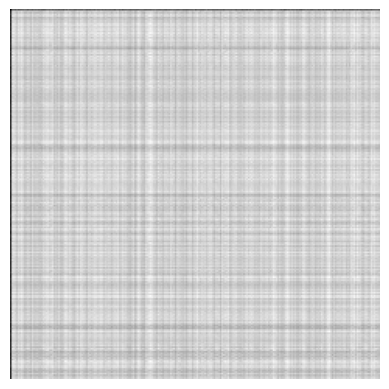

In [ ]:
testiter = iter(test_loader)

tensor, label, length = next(testiter) 
out_vhse = model(tensor)
print(out_vhse.shape)
out_vhse = out_vhse[0].squeeze(0).detach().numpy()
print(out_vhse)
printMap(out_vhse, length[0])